<a href="https://colab.research.google.com/github/hardik-05/Fid-Case-Study/blob/main/funds_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
asset_classes = ['bonds','large_cap','us_mid_cap','us_small_cap','large_foreign','emerging','commodities','s&p']
average_returns = [4.44,7.85,9.55,9.22,2.26,5.57,-2.62,7.89]
std_10_yrs = [3.29,14.32,17.68,19.55,18.21,23.60,18.11,14.74]
risk_profile = [1,3,3,4,4,5,5,2]
percent_fees = [0.01,0.003,0.003,0.003,0.01,0.015,0.064,0.005]

In [2]:
import numpy as np

def monte_carlo_simulation(name, mean_return, std_dev, num_iterations=100000):
    """
    Perform Monte Carlo simulation for an asset class.

    :param name: Name of the asset class
    :param mean_return: Mean annual return of the asset class
    :param std_dev: Standard deviation of the asset class
    :param num_iterations: Number of iterations for the simulation (default: 100000)
    :return: List of simulated returns
    """
    simulated_returns = np.random.normal(mean_return, std_dev, num_iterations)
    return simulated_returns.tolist()

# Given data
asset_classes = ['bonds', 'large_cap', 'us_mid_cap', 'us_small_cap', 'large_foreign', 'emerging', 'commodities', 's&p']
average_returns = [4.44, 7.85, 9.55, 9.22, 2.26, 5.57, -2.62, 7.89]
std_10_yrs = [3.29, 14.32, 17.68, 19.55, 18.21, 23.60, 18.11, 14.74]

# Perform Monte Carlo simulation for each asset class
simulations = {}
for asset, mean_return, std_dev in zip(asset_classes, average_returns, std_10_yrs):
    simulations[asset] = monte_carlo_simulation(asset, mean_return, std_dev)

# Print the first 5 simulated returns for each asset class
for asset, returns in simulations.items():
    print(f"{asset}: {returns[:5]}...")

# Optional: Calculate and print some statistics
for asset, returns in simulations.items():
    print(f"\n{asset}:")
    print(f"  Mean: {np.mean(returns):.2f}")
    print(f"  Std Dev: {np.std(returns):.2f}")
    print(f"  Min: {np.min(returns):.2f}")
    print(f"  Max: {np.max(returns):.2f}")

bonds: [6.0703426493865, 5.343142169166774, 5.543535312250783, 3.614596913971753, 3.184158571792789]...
large_cap: [13.24054481756911, 20.193017925952205, 4.718939926531981, 23.97684978040551, -13.794634342675382]...
us_mid_cap: [46.51358839361413, 1.8654253719160145, 39.99835869488344, 35.205315981677145, 16.873611325124255]...
us_small_cap: [-10.024562756941306, 29.838744440084405, 8.777428641776922, 12.051808436096255, 17.414639512417438]...
large_foreign: [-8.979982394967113, 40.65317031713529, -6.735922919359922, 18.976819325867396, 9.514845133347233]...
emerging: [41.837334506457765, 7.411349659593631, -4.400561949989326, 23.489021700709436, 5.458953094572133]...
commodities: [-15.531880044028451, -10.220910583440382, 34.29153779866887, -9.119669831454564, 26.48914812082185]...
s&p: [-2.424541908508977, 2.932313480123688, 14.296514381575083, -1.1393031262973592, -5.910414355430782]...

bonds:
  Mean: 4.44
  Std Dev: 3.28
  Min: -10.88
  Max: 18.50

large_cap:
  Mean: 7.83
  Std D

In [3]:
pip install numpy scipy matplotlib


Fund 1 (Target Risk Profile: 1):
Actual Risk Profile: 1.19
Expected Return: 4.52%
Asset Allocation:
  bonds: 93.00%
  large_cap: 1.00%
  us_mid_cap: 1.00%
  us_small_cap: 1.00%
  large_foreign: 1.00%
  emerging: 1.00%
  commodities: 1.00%
  s&p: 1.00%

Fund 2 (Target Risk Profile: 2):
Actual Risk Profile: 1.93
Expected Return: 7.33%
Asset Allocation:
  bonds: 12.50%
  large_foreign: 1.04%
  commodities: 1.04%
  s&p: 85.42%

Fund 3 (Target Risk Profile: 3):
Actual Risk Profile: 2.99
Expected Return: 9.18%
Asset Allocation:
  large_cap: 1.03%
  us_mid_cap: 92.78%
  us_small_cap: 1.03%
  emerging: 1.03%
  s&p: 4.12%

Fund 4 (Target Risk Profile: 4):
Actual Risk Profile: 4.02
Expected Return: 8.84%
Asset Allocation:
  large_cap: 1.03%
  us_mid_cap: 1.03%
  us_small_cap: 90.72%
  emerging: 6.19%
  s&p: 1.03%

Fund 5 (Target Risk Profile: 5):
Actual Risk Profile: 4.92
Expected Return: 5.56%
Asset Allocation:
  large_cap: 1.02%
  us_mid_cap: 1.02%
  us_small_cap: 1.02%
  emerging: 94.90%
  c

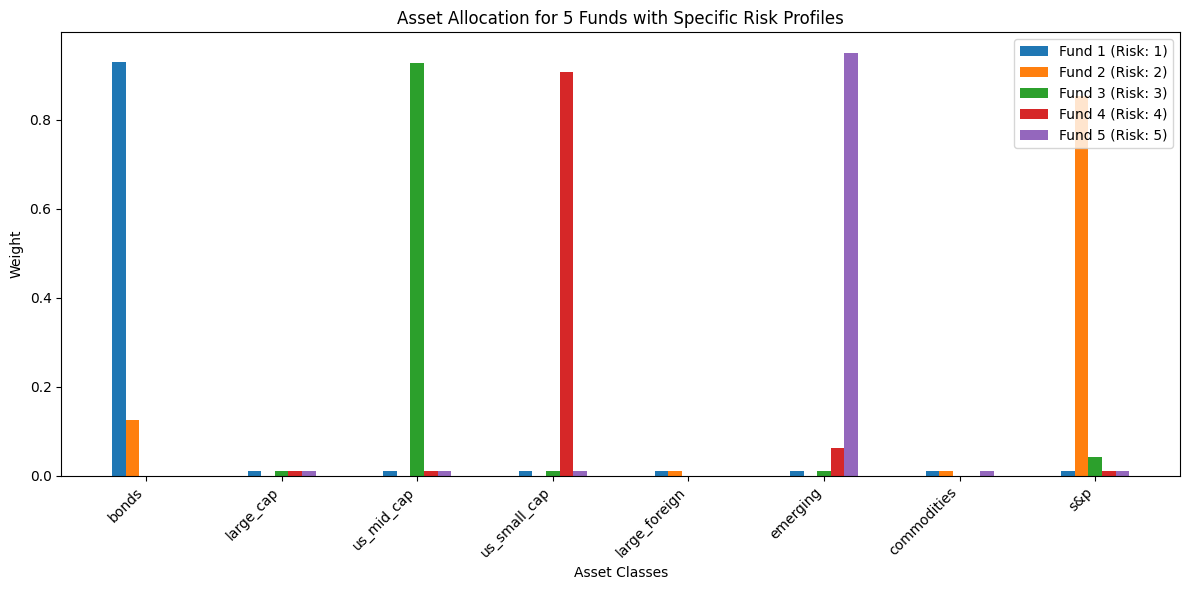

In [5]:
import numpy as np
from scipy.optimize import minimize

# Monte Carlo simulation function (unchanged)
def monte_carlo_simulation(name, mean_return, std_dev, num_iterations=100000):
    simulated_returns = np.random.normal(mean_return, std_dev, num_iterations)
    return simulated_returns.tolist()

# Given data
asset_classes = ['bonds', 'large_cap', 'us_mid_cap', 'us_small_cap', 'large_foreign', 'emerging', 'commodities', 's&p']
average_returns = [4.44, 7.85, 9.55, 9.22, 2.26, 5.57, -2.62, 7.89]
std_10_yrs = [3.29, 14.32, 17.68, 19.55, 18.21, 23.60, 18.11, 14.74]
risk_profile = [1, 3, 3, 4, 4, 5, 5, 2]

# Perform Monte Carlo simulation for each asset class
simulations = {}
for asset, mean_return, std_dev in zip(asset_classes, average_returns, std_10_yrs):
    simulations[asset] = monte_carlo_simulation(asset, mean_return, std_dev)

# Calculate average returns from simulations
avg_returns = {asset: np.mean(returns) for asset, returns in simulations.items()}

def objective(weights):
    return -np.sum(weights * [avg_returns[asset] for asset in asset_classes])

def risk_constraint(weights, target_risk):
    return np.abs(np.sum(weights * risk_profile) - target_risk)

def create_fund(target_risk, min_assets=3, max_assets=8, min_weight=0.01):
    bounds = [(min_weight, 1.0) for _ in range(len(asset_classes))]
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'eq', 'fun': lambda w: risk_constraint(w, target_risk)},
        {'type': 'ineq', 'fun': lambda w: np.sum(w > min_weight) - min_assets},
        {'type': 'ineq', 'fun': lambda w: max_assets - np.sum(w > min_weight)}
    ]

    result = minimize(objective, [1/len(asset_classes)]*len(asset_classes), method='SLSQP', bounds=bounds, constraints=constraints)

    weights = result.x
    weights[weights < min_weight] = 0
    weights = weights / np.sum(weights)

    fund_risk = np.sum(weights * risk_profile)
    fund_return = -result.fun

    return weights, fund_risk, fund_return

# Create 5 funds for different risk profiles
funds = []
target_risks = [1, 2, 3, 4, 5]

for target_risk in target_risks:
    weights, fund_risk, fund_return = create_fund(target_risk)
    funds.append({
        'target_risk': target_risk,
        'weights': weights,
        'actual_risk': fund_risk,
        'expected_return': fund_return
    })

# Print fund compositions and statistics
for i, fund in enumerate(funds, 1):
    print(f"\nFund {i} (Target Risk Profile: {fund['target_risk']}):")
    print(f"Actual Risk Profile: {fund['actual_risk']:.2f}")
    print(f"Expected Return: {fund['expected_return']:.2f}%")
    print("Asset Allocation:")
    for asset, weight in zip(asset_classes, fund['weights']):
        if weight > 0.01:
            print(f"  {asset}: {weight*100:.2f}%")

# Visualize the funds
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

for i, fund in enumerate(funds):
    ax.bar(np.arange(len(asset_classes)) + i*0.1, fund['weights'], width=0.1, label=f"Fund {i+1} (Risk: {fund['target_risk']})")

ax.set_xlabel('Asset Classes')
ax.set_ylabel('Weight')
ax.set_title('Asset Allocation for 5 Funds with Specific Risk Profiles')
ax.set_xticks(np.arange(len(asset_classes)) + 0.2)
ax.set_xticklabels(asset_classes, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


Fund 1 (Risk Profile: 1, Max Fee: 0.50%):
Actual Risk Profile: 1.69
Expected Return: 6.34%
Actual Fee: 0.77%
Asset Allocation:
  bonds: 41.39%
  large_cap: 1.01%
  us_mid_cap: 1.01%
  us_small_cap: 1.01%
  emerging: 1.01%
  commodities: 1.01%
  s&p: 53.56%

Fund 2 (Risk Profile: 2, Max Fee: 0.75%):
Actual Risk Profile: 1.95
Expected Return: 7.44%
Actual Fee: 0.57%
Asset Allocation:
  bonds: 12.24%
  large_cap: 1.02%
  us_mid_cap: 1.02%
  us_small_cap: 1.02%
  emerging: 1.02%
  s&p: 83.67%

Fund 3 (Risk Profile: 3, Max Fee: 1.00%):
Actual Risk Profile: 2.99
Expected Return: 9.35%
Actual Fee: 0.32%
Asset Allocation:
  large_cap: 1.03%
  us_mid_cap: 92.78%
  us_small_cap: 1.03%
  emerging: 1.03%
  s&p: 4.12%

Fund 4 (Risk Profile: 4, Max Fee: 1.25%):
Actual Risk Profile: 4.02
Expected Return: 9.02%
Actual Fee: 0.38%
Asset Allocation:
  large_cap: 1.03%
  us_mid_cap: 1.03%
  us_small_cap: 90.72%
  emerging: 6.19%
  s&p: 1.03%

Fund 5 (Risk Profile: 5, Max Fee: 1.50%):
Actual Risk Profile:

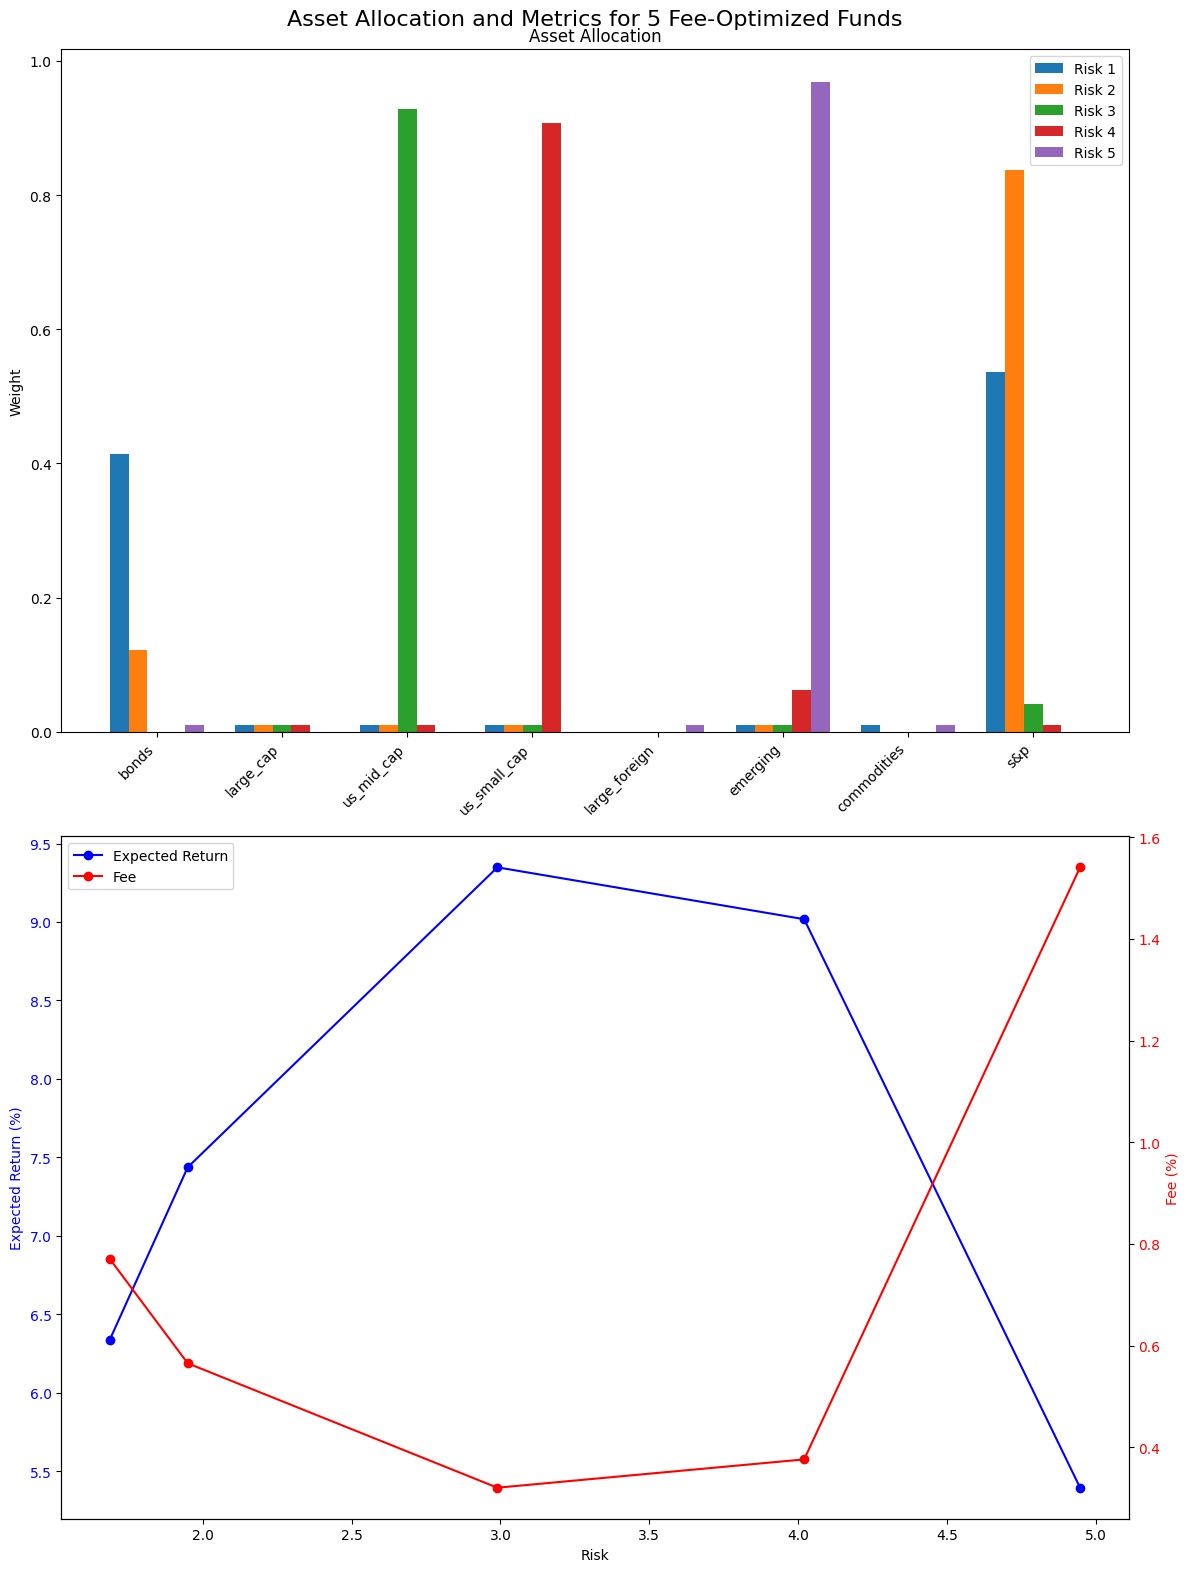

In [7]:
import numpy as np
from scipy.optimize import minimize

def monte_carlo_simulation(name, mean_return, std_dev, num_iterations=100000):
    simulated_returns = np.random.normal(mean_return, std_dev, num_iterations)
    return simulated_returns.tolist()

# Given data
asset_classes = ['bonds', 'large_cap', 'us_mid_cap', 'us_small_cap', 'large_foreign', 'emerging', 'commodities', 's&p']
average_returns = [4.44, 7.85, 9.55, 9.22, 2.26, 5.57, -2.62, 7.89]
std_10_yrs = [3.29, 14.32, 17.68, 19.55, 18.21, 23.60, 18.11, 14.74]
risk_profile = [1, 3, 3, 4, 4, 5, 5, 2]
percent_fees = [0.01, 0.003, 0.003, 0.003, 0.01, 0.015, 0.064, 0.005]

# Perform Monte Carlo simulation for each asset class
simulations = {}
for asset, mean_return, std_dev in zip(asset_classes, average_returns, std_10_yrs):
    simulations[asset] = monte_carlo_simulation(asset, mean_return, std_dev)

# Calculate average returns from simulations
avg_returns = {asset: np.mean(returns) for asset, returns in simulations.items()}

def objective(weights):
    return -np.sum(weights * [avg_returns[asset] for asset in asset_classes])

def risk_constraint(weights, target_risk):
    return np.abs(np.sum(weights * risk_profile) - target_risk)

def fee_constraint(weights, max_fee):
    return max_fee - np.sum(weights * percent_fees)

def create_fund(target_risk, max_fee, min_assets=3, max_assets=8, min_weight=0.01):
    bounds = [(min_weight, 1.0) for _ in range(len(asset_classes))]
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'eq', 'fun': lambda w: risk_constraint(w, target_risk)},
        {'type': 'ineq', 'fun': lambda w: fee_constraint(w, max_fee)},
        {'type': 'ineq', 'fun': lambda w: np.sum(w > min_weight) - min_assets},
        {'type': 'ineq', 'fun': lambda w: max_assets - np.sum(w > min_weight)}
    ]

    result = minimize(objective,
                      [1/len(asset_classes)]*len(asset_classes),
                      method='SLSQP',
                      bounds=bounds,
                      constraints=constraints)

    weights = result.x
    weights[weights < min_weight] = 0
    weights = weights / np.sum(weights)

    fund_risk = np.sum(weights * risk_profile)
    fund_return = np.sum(weights * [avg_returns[asset] for asset in asset_classes])
    fund_fee = np.sum(weights * percent_fees)

    return weights, fund_risk, fund_return, fund_fee

# Create 5 funds for different risk profiles with fee optimization
funds = []
target_risks = [1, 2, 3, 4, 5]
max_fees = [0.005, 0.0075, 0.01, 0.0125, 0.015]  # Example max fees for each risk profile

for target_risk, max_fee in zip(target_risks, max_fees):
    weights, fund_risk, fund_return, fund_fee = create_fund(target_risk, max_fee)
    funds.append({
        'target_risk': target_risk,
        'max_fee': max_fee,
        'weights': weights,
        'actual_risk': fund_risk,
        'expected_return': fund_return,
        'actual_fee': fund_fee
    })

# Print fund compositions and statistics
for i, fund in enumerate(funds, 1):
    print(f"\nFund {i} (Risk Profile: {fund['target_risk']}, Max Fee: {fund['max_fee']*100:.2f}%):")
    print(f"Actual Risk Profile: {fund['actual_risk']:.2f}")
    print(f"Expected Return: {fund['expected_return']:.2f}%")
    print(f"Actual Fee: {fund['actual_fee']*100:.2f}%")
    print("Asset Allocation:")
    for asset, weight in zip(asset_classes, fund['weights']):
        if weight > 0.01:
            print(f"  {asset}: {weight*100:.2f}%")

# Visualize the funds
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16))
fig.suptitle('Asset Allocation and Metrics for 5 Fee-Optimized Funds', fontsize=16)

# Asset allocation plot
for i, fund in enumerate(funds):
    ax1.bar(np.arange(len(asset_classes)) + i*0.15, fund['weights'], width=0.15,
            label=f"Risk {fund['target_risk']}")

ax1.set_ylabel('Weight')
ax1.set_title('Asset Allocation')
ax1.set_xticks(np.arange(len(asset_classes)) + 0.3)
ax1.set_xticklabels(asset_classes, rotation=45, ha='right')
ax1.legend()

# Risk, return, and fee plot
risks = [fund['actual_risk'] for fund in funds]
returns = [fund['expected_return'] for fund in funds]
fees = [fund['actual_fee'] * 100 for fund in funds]

ax2.plot(risks, returns, 'bo-', label='Expected Return')
ax2.set_xlabel('Risk')
ax2.set_ylabel('Expected Return (%)', color='b')
ax2.tick_params(axis='y', labelcolor='b')

ax3 = ax2.twinx()
ax3.plot(risks, fees, 'ro-', label='Fee')
ax3.set_ylabel('Fee (%)', color='r')
ax3.tick_params(axis='y', labelcolor='r')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

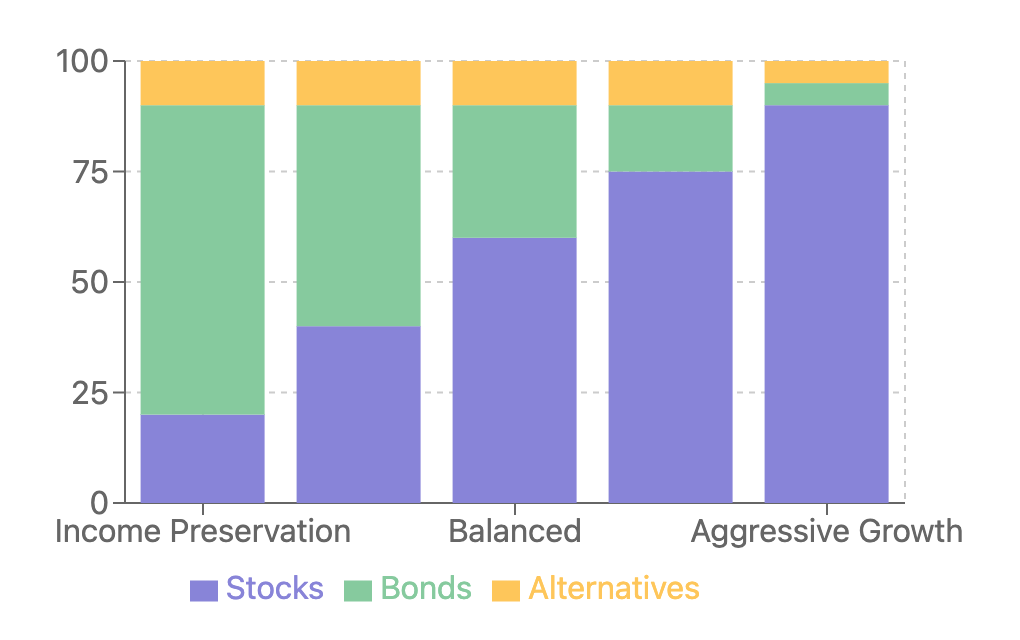

In [12]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# Given data
asset_classes = ['bonds', 'large_cap', 'us_mid_cap', 'us_small_cap', 'large_foreign', 'emerging', 'commodities', 's&p']
average_returns = [4.44, 7.85, 9.55, 9.22, 2.26, 5.57, -2.62, 7.89]
std_10_yrs = [3.29, 14.32, 17.68, 19.55, 18.21, 23.60, 18.11, 14.74]
risk_profile = [1, 3, 3, 4, 4, 5, 5, 2]
percent_fees = [0.01, 0.003, 0.003, 0.003, 0.01, 0.015, 0.064, 0.005]

# Monte Carlo simulation
def monte_carlo_simulation(returns, stds, num_simulations=100000):
    return np.random.normal(returns, stds, (num_simulations, len(returns)))

simulations = monte_carlo_simulation(average_returns, std_10_yrs)

# Calculate min, max, and mean returns for each asset class
min_returns = np.min(simulations, axis=0)
max_returns = np.max(simulations, axis=0)
mean_returns = np.mean(simulations, axis=0)

# Define goal-based funds
funds = [
    {"name": "Retirement Builder", "target_risk": 3.5, "min_bonds": 0.2},
    {"name": "Education Savings", "target_risk": 3.0, "min_bonds": 0.3},
    {"name": "Income Generation", "target_risk": 2.0, "min_bonds": 0.5},
    {"name": "First Home Buyer's", "target_risk": 3.0, "min_bonds": 0.3},
    {"name": "Wealth Accumulation", "target_risk": 4.0, "min_bonds": 0.1},
]

# Function to calculate weighted risk score
def weighted_risk_score(weights):
    return np.sum(weights * risk_profile)

# Function to calculate weighted return
def weighted_return(weights):
    return np.sum(weights * average_returns)

# Function to calculate weighted fee
def weighted_fee(weights):
    return np.sum(weights * percent_fees)

# Optimization function
def optimize_fund(target_risk, min_bonds):
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: w[0] - min_bonds},
        {'type': 'ineq', 'fun': lambda w: weighted_risk_score(w) - (target_risk - 0.5)},
        {'type': 'ineq', 'fun': lambda w: (target_risk + 0.5) - weighted_risk_score(w)}
    ]
    bounds = [(0, 1) for _ in range(len(asset_classes))]
    result = minimize(lambda w: -weighted_return(w), [1/len(asset_classes)]*len(asset_classes),
                      method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

# Optimize each fund
for fund in funds:
    weights = optimize_fund(fund['target_risk'], fund['min_bonds'])
    fund['weights'] = weights
    fund['risk_score'] = weighted_risk_score(weights)
    fund['expected_return'] = weighted_return(weights)
    fund['fee'] = weighted_fee(weights)

# Print results
print("Goal-Based Funds Analysis:")
for fund in funds:
    print(f"\n{fund['name']}:")
    print(f"Risk Score: {fund['risk_score']:.2f}")
    print(f"Expected Return: {fund['expected_return']:.2f}%")
    print(f"Fee: {fund['fee']*100:.2f}%")
    print("Asset Allocation:")
    for asset, weight in zip(asset_classes, fund['weights']):
        print(f"  {asset}: {weight*100:.2f}%")

# Calculate overall min, max, and mean fees
all_weights = np.array([fund['weights'] for fund in funds])
min_fees = np.min(np.dot(all_weights, percent_fees)) * 100
max_fees = np.max(np.dot(all_weights, percent_fees)) * 100
mean_fees = np.mean(np.dot(all_weights, percent_fees)) * 100

print(f"\nOverall Fee Analysis:")
print(f"Min Fee: {min_fees:.2f}%")
print(f"Max Fee: {max_fees:.2f}%")
print(f"Mean Fee: {mean_fees:.2f}%")

# Print min, max, and mean returns for each asset class
print("\nAsset Class Return Analysis:")
for asset, min_ret, max_ret, mean_ret in zip(asset_classes, min_returns, max_returns, mean_returns):
    print(f"{asset}:")
    print(f"  Min Return: {min_ret:.2f}%")
    print(f"  Max Return: {max_ret:.2f}%")
    print(f"  Mean Return: {mean_ret:.2f}%")

Goal-Based Funds Analysis:

Retirement Builder:
Risk Score: 3.00
Expected Return: 8.40%
Fee: 0.44%
Asset Allocation:
  bonds: 20.00%
  large_cap: 0.00%
  us_mid_cap: 40.00%
  us_small_cap: 40.00%
  large_foreign: 0.00%
  emerging: 0.00%
  commodities: 0.00%
  s&p: 0.00%

Education Savings:
Risk Score: 2.50
Expected Return: 7.98%
Fee: 0.51%
Asset Allocation:
  bonds: 30.00%
  large_cap: 0.00%
  us_mid_cap: 60.00%
  us_small_cap: 10.00%
  large_foreign: 0.00%
  emerging: 0.00%
  commodities: 0.00%
  s&p: 0.00%

Income Generation:
Risk Score: 2.00
Expected Return: 7.00%
Fee: 0.65%
Asset Allocation:
  bonds: 50.00%
  large_cap: 0.00%
  us_mid_cap: 50.00%
  us_small_cap: 0.00%
  large_foreign: 0.00%
  emerging: 0.00%
  commodities: 0.00%
  s&p: 0.00%

First Home Buyer's:
Risk Score: 2.50
Expected Return: 7.98%
Fee: 0.51%
Asset Allocation:
  bonds: 30.00%
  large_cap: 0.00%
  us_mid_cap: 60.00%
  us_small_cap: 10.00%
  large_foreign: 0.00%
  emerging: 0.00%
  commodities: 0.00%
  s&p: 0.00%


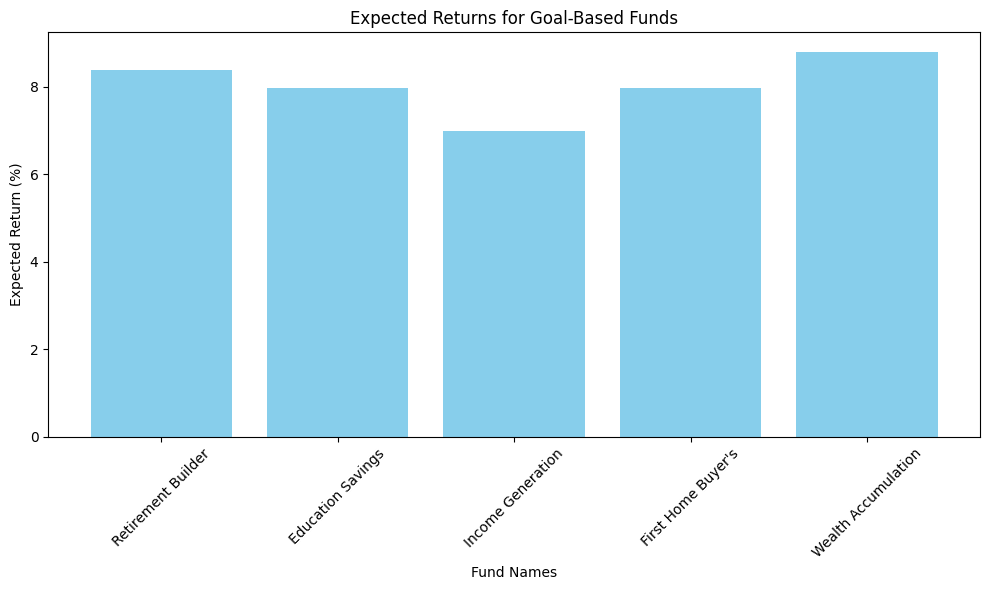

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Given data
asset_classes = ['bonds', 'large_cap', 'us_mid_cap', 'us_small_cap', 'large_foreign', 'emerging', 'commodities', 's&p']
average_returns = [4.44, 7.85, 9.55, 9.22, 2.26, 5.57, -2.62, 7.89]
std_10_yrs = [3.29, 14.32, 17.68, 19.55, 18.21, 23.60, 18.11, 14.74]
risk_profile = [1, 3, 3, 4, 4, 5, 5, 2]
percent_fees = [0.01, 0.003, 0.003, 0.003, 0.01, 0.015, 0.064, 0.005]

# Monte Carlo simulation
def monte_carlo_simulation(returns, stds, num_simulations=100000):
    return np.random.normal(returns, stds, (num_simulations, len(returns)))

simulations = monte_carlo_simulation(average_returns, std_10_yrs)

# Calculate min, max, and mean returns for each asset class
min_returns = np.min(simulations, axis=0)
max_returns = np.max(simulations, axis=0)
mean_returns = np.mean(simulations, axis=0)

# Define goal-based funds
funds = [
    {"name": "Retirement Builder", "target_risk": 3.5, "min_bonds": 0.2},
    {"name": "Education Savings", "target_risk": 3.0, "min_bonds": 0.3},
    {"name": "Income Generation", "target_risk": 2.0, "min_bonds": 0.5},
    {"name": "First Home Buyer's", "target_risk": 3.0, "min_bonds": 0.3},
    {"name": "Wealth Accumulation", "target_risk": 4.0, "min_bonds": 0.1},
]

# Function to calculate weighted risk score
def weighted_risk_score(weights):
    return np.sum(weights * risk_profile)

# Function to calculate weighted return
def weighted_return(weights):
    return np.sum(weights * average_returns)

# Function to calculate weighted fee
def weighted_fee(weights):
    return np.sum(weights * percent_fees)

# Optimization function
def optimize_fund(target_risk, min_bonds):
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: w[0] - min_bonds},
        {'type': 'ineq', 'fun': lambda w: weighted_risk_score(w) - (target_risk - 0.5)},
        {'type': 'ineq', 'fun': lambda w: (target_risk + 0.5) - weighted_risk_score(w)}
    ]
    bounds = [(0, 1) for _ in range(len(asset_classes))]
    result = minimize(lambda w: -weighted_return(w), [1/len(asset_classes)]*len(asset_classes),
                      method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

# Optimize each fund
for fund in funds:
    weights = optimize_fund(fund['target_risk'], fund['min_bonds'])
    fund['weights'] = weights
    fund['risk_score'] = weighted_risk_score(weights)
    fund['expected_return'] = weighted_return(weights)
    fund['fee'] = weighted_fee(weights)

# Plotting the returns for each fund
fund_names = [fund['name'] for fund in funds]
fund_returns = [fund['expected_return'] for fund in funds]

plt.figure(figsize=(10, 6))
plt.bar(fund_names, fund_returns, color='skyblue')
plt.xlabel('Fund Names')
plt.ylabel('Expected Return (%)')
plt.title('Expected Returns for Goal-Based Funds')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()


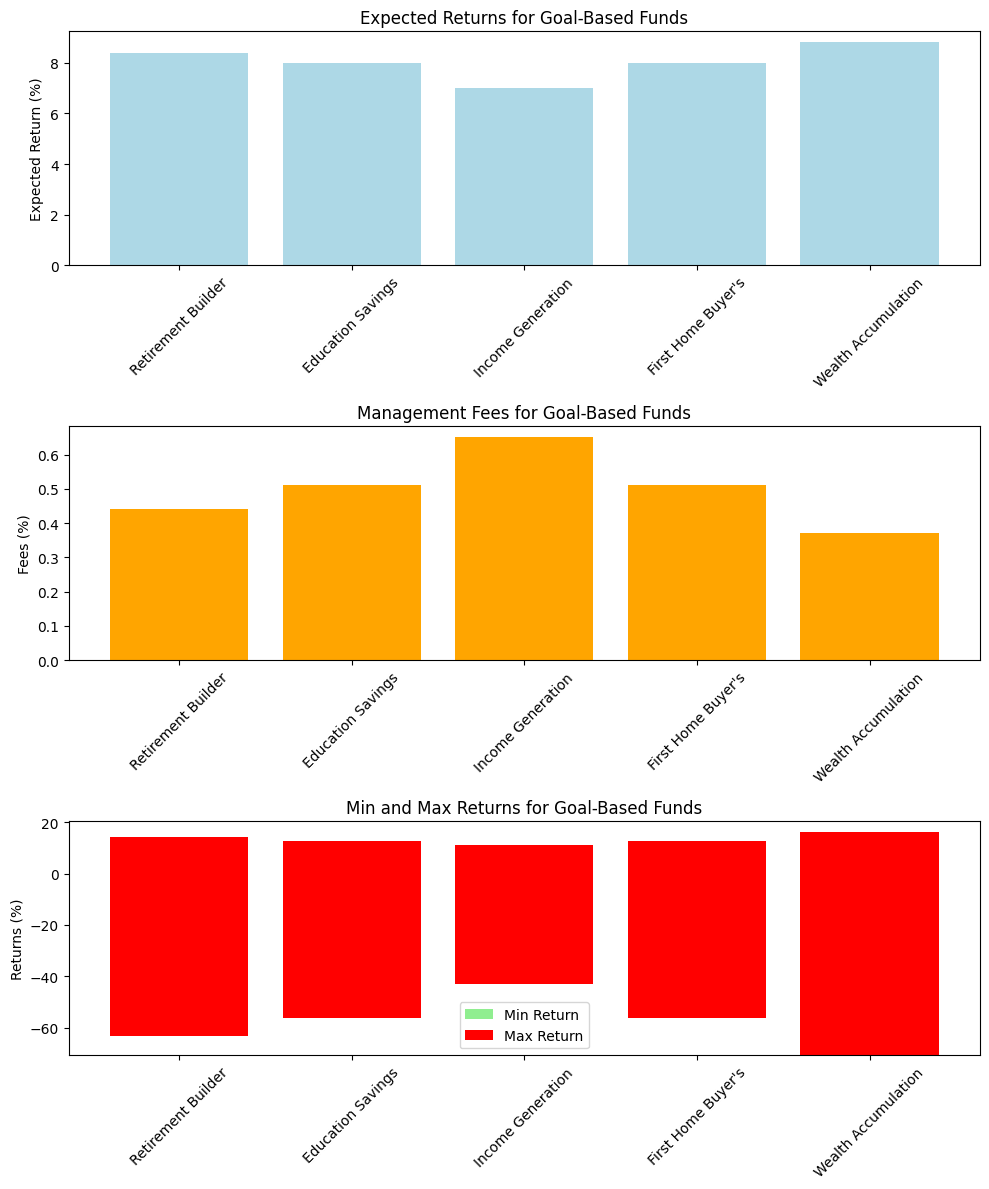

In [14]:
# Ensure fund names are properly assigned
fund_names = ['Retirement Builder', 'Education Savings', 'Income Generation',
              'First Home Buyer\'s', 'Wealth Accumulation']

# Extract fund data for plotting
fund_returns = [fund['expected_return'] for fund in funds]
fund_fees = [fund['fee'] * 100 for fund in funds]  # Converting fees to percentage
fund_weights = [fund['weights'] for fund in funds]

# Calculate the min and max returns based on the weights for each fund
fund_min_returns = [np.sum(weights * min_returns) for weights in fund_weights]
fund_max_returns = [np.sum(weights * max_returns) for weights in fund_weights]

# Create a subplot to visualize the returns, fees, and min/max returns
fig, ax = plt.subplots(3, 1, figsize=(10, 12))

# Plot expected returns for each fund
ax[0].bar(fund_names, fund_returns, color='lightblue')
ax[0].set_title('Expected Returns for Goal-Based Funds')
ax[0].set_ylabel('Expected Return (%)')
ax[0].tick_params(axis='x', rotation=45)

# Plot fees for each fund
ax[1].bar(fund_names, fund_fees, color='orange')
ax[1].set_title('Management Fees for Goal-Based Funds')
ax[1].set_ylabel('Fees (%)')
ax[1].tick_params(axis='x', rotation=45)

# Plot min and max returns for each fund
ax[2].bar(fund_names, fund_min_returns, color='lightgreen', label='Min Return')
ax[2].bar(fund_names, fund_max_returns, bottom=fund_min_returns, color='red', label='Max Return')
ax[2].set_title('Min and Max Returns for Goal-Based Funds')
ax[2].set_ylabel('Returns (%)')
ax[2].tick_params(axis='x', rotation=45)
ax[2].legend()

# Adjust layout and display the plots
plt.tight_layout()
plt.show()


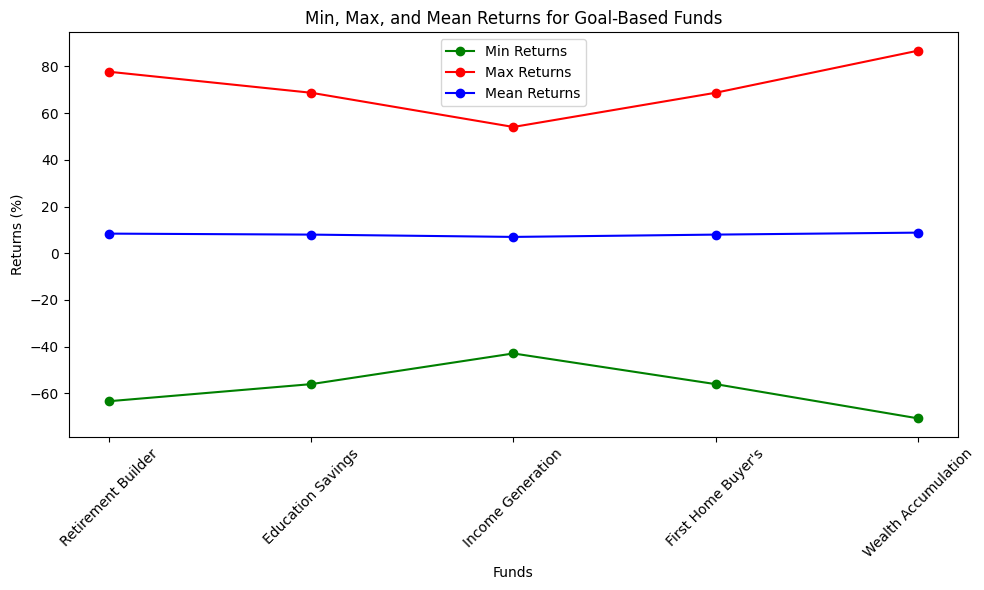

In [15]:
import matplotlib.pyplot as plt

# Ensure fund names are properly assigned
fund_names = ['Retirement Builder', 'Education Savings', 'Income Generation',
              'First Home Buyer\'s', 'Wealth Accumulation']

# Calculate mean returns based on the weights
fund_mean_returns = [np.sum(weights * mean_returns) for weights in fund_weights]

# Create a line chart to visualize min, max, and mean returns for each fund
plt.figure(figsize=(10, 6))

# Plot min returns
plt.plot(fund_names, fund_min_returns, marker='o', label='Min Returns', color='green')

# Plot max returns
plt.plot(fund_names, fund_max_returns, marker='o', label='Max Returns', color='red')

# Plot mean returns
plt.plot(fund_names, fund_mean_returns, marker='o', label='Mean Returns', color='blue')

# Adding title and labels
plt.title('Min, Max, and Mean Returns for Goal-Based Funds')
plt.ylabel('Returns (%)')
plt.xlabel('Funds')
plt.xticks(rotation=45)

# Add legend to distinguish between lines
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()
